# VAE / Perceptual VAE / cVAE on CIFAR-10

**Sections**
1. Setup & Imports
2. Dataset & Config
3. Building Blocks (ResBlock, AdaGN)
4. Encoder & Decoder
5. Model Definitions (VAE · PercepVAE · cVAE)
6. Perceptual Loss
7. Training Loop
8. Evaluation (FID & IS)
9. Visualisations (Reconstructions & Latent Space)

## 1 · Setup & Imports

In [ ]:
#  install extra deps (run once)
# !pip install torchmetrics

In [ ]:
import os, math, random
from dataclasses import dataclass, field
from typing import List, Optional, Callable

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
from dataclasses import dataclass, asdict
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.models import vgg16, VGG16_Weights

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# reproducibility
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

c:\Users\MohamedAtia.Emam\AppData\Local\miniconda3\envs\SegDec_Proj\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2 · Dataset & Config

In [ ]:
@dataclass
class Config:
    # data
    data_root:     str   = "./data"
    image_size:    int   = 32
    num_classes:   int   = 10
    # architecture
    latent_dim:    int   = 128
    base_channels: int   = 64          # channel multiplier base
    channel_mults: List  = field(default_factory=lambda: [1, 2, 4])
    num_res_blocks:int   = 2
    # training
    batch_size:    int   = 128
    lr:            float = 2e-4
    epochs:        int   = 30
    kl_weight:     float = .1        # β in β-VAE
    percep_weight: float = 0.1
    # misc
    num_workers:   int   = 4
    log_every:     int   = 5           # epochs
    sample_n:      int   = 64          # images per visualisation grid
    use_attention: bool = False
    attn_heads: int = 4

CFG = Config()

In [ ]:
def create_experiment(folder_name, base_path="."):
    base_path = Path(base_path)
    folder_path = base_path / folder_name

    counter = 1

    while folder_path.exists():
        folder_path = base_path / f"{folder_name}_{counter}"
        counter += 1

    folder_path.mkdir(parents=True, exist_ok=False)

    with open(folder_path/"config.json", "w", encoding="utf-8") as f:
        json.dump(asdict(CFG), f, indent=4)

    return str(folder_path)


# Example usage
# experiment_dir = create_experiment("with_KL_equals_one_over_ten_for_30_epoch_with_atten_interpolation_upsampling")

In [99]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat",
    "deer", "dog", "frog", "horse", "ship", "truck"
]

train_tf = T.Compose([
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
])
test_tf = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*3, [0.5]*3),
])

train_ds = torchvision.datasets.CIFAR10(CFG.data_root, train=True,  download=True, transform=train_tf)
test_ds  = torchvision.datasets.CIFAR10(CFG.data_root, train=False, download=True, transform=test_tf)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False)

print(f"Train: {len(train_ds):,}  |  Test: {len(test_ds):,}")

Train: 50,000  |  Test: 10,000


## 3 · Building Blocks

In [119]:
class DownSample(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.c1 = nn.Conv2d(in_ch, in_ch, 3, stride=2, padding=1)
        self.c2 = nn.Conv2d(in_ch, in_ch, 5, stride=2, padding=2)

    def forward(self, x):
        x = self.c1(x) + self.c2(x)
        return x


class UpSample(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.c = nn.Conv2d(in_ch, in_ch, 3, stride=1, padding=1)
        self.t = nn.ConvTranspose2d(in_ch, in_ch, 5, 2, 2, 1)

    def forward(self, x):
        _, _, H, W = x.shape
        x = self.t(x)
        x = self.c(x)
        return x

In [ ]:

# helpers

def norm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(min(8, channels), channels)


# AdaGN: Adaptive Group Normalisation
class AdaGN(nn.Module):

    def __init__(self, channels: int, cond_dim: int):
        super().__init__()

        # Normalize feature maps without learnable affine parameters
        self.norm = nn.GroupNorm(
            num_groups=min(8, channels),
            num_channels=channels,
            affine=False,
        )

        # Predict per-channel scale and bias from conditioning input
        self.to_scale_shift = nn.Linear(cond_dim, channels * 2)

    def forward(self, x, cond):

        # Step 1: Normalize input features
        x_norm = self.norm(x)

        # Step 2: Generate scale and bias from conditioning vector
        scale, shift = self.to_scale_shift(cond).chunk(2, dim=-1)

        # Reshape for broadcasting over spatial dimensions
        scale = scale[:, :, None, None]
        shift = shift[:, :, None, None]

        # Step 3: Apply adaptive modulation
        return (1 + scale) * x_norm + shift


# Attention Block
# class AttentionBlock(nn.Module):
#     def __init__(self, channels: int, num_heads: int = 4):
#         super().__init__()
#         self.norm = norm(channels)
#         self.attn = nn.MultiheadAttention(
#             embed_dim=channels,
#             num_heads=num_heads,
#             batch_first=True
#         )

#     def forward(self, x):
#         b, c, h, w = x.shape
#         residual = x

#         x = self.norm(x)
#         x = x.view(b, c, h * w).transpose(1, 2)

#         x, _ = self.attn(x, x, x)

#         x = x.transpose(1, 2).view(b, c, h, w)
#         return x + residual

class AttnBlock(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.group_norm = nn.GroupNorm(32, in_ch)
        self.proj_q = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj_k = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj_v = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)
        self.proj = nn.Conv2d(in_ch, in_ch, 1, stride=1, padding=0)

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.group_norm(x)
        q = self.proj_q(h)
        k = self.proj_k(h)
        v = self.proj_v(h)

        q = q.permute(0, 2, 3, 1).view(B, H * W, C)
        k = k.view(B, C, H * W)
        w = torch.bmm(q, k) * (int(C) ** (-0.5))
        assert list(w.shape) == [B, H * W, H * W]
        w = F.softmax(w, dim=-1)

        v = v.permute(0, 2, 3, 1).view(B, H * W, C)
        h = torch.bmm(w, v)
        assert list(h.shape) == [B, H * W, C]
        h = h.view(B, H, W, C).permute(0, 3, 1, 2)
        h = self.proj(h)

        return x + h


class ResBlock(nn.Module):
    def __init__(
        self,
        in_ch: int,
        out_ch: int,
        cond_dim: int | None = None,
        use_attention: bool = False,
        num_heads: int = 4,
        stride: int = 1
    ):
        super().__init__()

        self.cond_dim = cond_dim

        if cond_dim is None:
            self.norm1 = norm(in_ch)
            self.norm2 = norm(out_ch)
        else:
            self.norm1 = AdaGN(in_ch, cond_dim)
            self.norm2 = AdaGN(out_ch, cond_dim)

        self.conv1 = nn.Conv2d(
            in_ch, out_ch, 3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.conv2 = nn.Conv2d(
            out_ch, out_ch, 3,
            padding=1,
            bias=False
        )

        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False)
            if (in_ch != out_ch or stride != 1)
            else nn.Identity()
        )

        self.attn = (
            AttentionBlock(out_ch, num_heads)
            if use_attention else nn.Identity()
        )

    def forward(self, x, c=None):
        residual = self.skip(x)

        if self.cond_dim is None:
            h = self.conv1(F.silu(self.norm1(x)))
            h = self.conv2(F.silu(self.norm2(h)))
        else:
            h = self.conv1(F.silu(self.norm1(x, c)))
            h = self.conv2(F.silu(self.norm2(h, c)))

        h = h + residual
        h = self.attn(h)

        return h

## 4 · Encoder & Decoder

In [ ]:

class Encoder(nn.Module):
    def __init__(
        self,
        in_ch: int,
        base_ch: int,
        channel_mults: List[int],
        num_res_blocks: int,
        latent_dim: int,
        use_attention: bool = True,
        attn_heads: int = 4
    ):
        super().__init__()

        ch = base_ch
        self.input_conv = nn.Conv2d(in_ch, ch, 3, padding=1)

        self.blocks = nn.ModuleList()

        for i, mult in enumerate(channel_mults):
            out_ch = base_ch * mult

            for _ in range(num_res_blocks):
                self.blocks.append(
                    ResBlock(
                        ch,
                        out_ch,
                        use_attention=use_attention,
                        num_heads=attn_heads
                    )
                )
                ch = out_ch

            if i < len(channel_mults) - 1:
                self.blocks.append(
                    DownSample(ch)
                )

        self.mid = nn.Sequential(
            ResBlock(
                ch, ch,
                use_attention=use_attention,
                num_heads=attn_heads
            ),
            norm(ch),
            nn.SiLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(ch, latent_dim)
        self.fc_logv = nn.Linear(ch, latent_dim)

    def forward(self, x):
        h = self.input_conv(x)

        for block in self.blocks:
            h = block(h)

        h = self.mid(h)

        return self.fc_mu(h), self.fc_logv(h)


class Decoder(nn.Module):
    def __init__(
        self,
        out_ch: int,
        base_ch: int,
        channel_mults: List[int],
        num_res_blocks: int,
        latent_dim: int,
        img_size: int,
        cond_dim: int | None = None,
        use_attention: bool = True,
        attn_heads: int = 4
    ):
        super().__init__()

        mults = list(reversed(channel_mults))

        n_down = len(channel_mults) - 1
        self.h0 = img_size // (2 ** n_down)

        ch = base_ch * mults[0]

        self.fc = nn.Linear(
            latent_dim,
            ch * self.h0 * self.h0
        )

        self.ch = ch

        self.blocks = nn.ModuleList()
        self.ups = nn.ModuleList()

        for i, mult in enumerate(mults):
            out_ch_d = base_ch * mult

            for _ in range(num_res_blocks):
                self.blocks.append(
                    ResBlock(
                        ch,
                        out_ch_d,
                        cond_dim=cond_dim,
                        use_attention=use_attention,
                        num_heads=attn_heads
                    )
                )
                ch = out_ch_d

            if i < len(mults) - 1:
                self.ups.append(
                    UpSample(ch)
                )
            else:
                self.ups.append(None)

        self.out = nn.Sequential(
            norm(ch),
            nn.SiLU(),
            nn.Conv2d(ch, out_ch, 3, padding=1)
        )

        self.num_res_blocks = num_res_blocks

    def forward(self, z, c=None):
        h = self.fc(z).view(-1, self.ch, self.h0, self.h0)

        idx = 0

        for up in self.ups:
            for _ in range(self.num_res_blocks):
                h = self.blocks[idx](h, c)
                idx += 1

            if up is not None:
                h = up(h)

        return torch.tanh(self.out(h))



## 5 · Model Definitions

In [ ]:
def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    if not torch.is_grad_enabled():
        return mu

    std = torch.exp(0.5 * logvar)
    return mu + std * torch.randn_like(std)


# VAE
class VAE(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()

        self.encoder = Encoder(
            3,
            cfg.base_channels,
            cfg.channel_mults,
            cfg.num_res_blocks,
            cfg.latent_dim,
            use_attention=cfg.use_attention,
            attn_heads=cfg.attn_heads
        )

        self.decoder = Decoder(
            3,
            cfg.base_channels,
            cfg.channel_mults,
            cfg.num_res_blocks,
            cfg.latent_dim,
            cfg.image_size,
            use_attention=cfg.use_attention,
            attn_heads=cfg.attn_heads
        )

        self.latent_dim = cfg.latent_dim

    def forward(self, x):
        mu, logvar = self.encoder(x)

        z = reparameterize(mu, logvar)

        recon = self.decoder(z)

        return recon, mu, logvar

    @torch.no_grad()
    def sample(self, n: int, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)


# Perceptual VAE
class PercepVAE(VAE):
    pass


# Conditional VAE
class cVAE(nn.Module):
    def __init__(self, cfg: Config, conditioning_mode: str = "adagn"):
        super().__init__()

        assert conditioning_mode in ("adagn", "concat")

        self.mode = conditioning_mode
        self.latent_dim = cfg.latent_dim
        self.emb_dim = 128

        self.class_emb = nn.Embedding(
            cfg.num_classes,
            self.emb_dim
        )

        self.encoder = Encoder(
            3,
            cfg.base_channels,
            cfg.channel_mults,
            cfg.num_res_blocks,
            cfg.latent_dim,
            use_attention=cfg.use_attention,
            attn_heads=cfg.attn_heads
        )

        if conditioning_mode == "adagn":
            self.decoder = Decoder(
                3,
                cfg.base_channels,
                cfg.channel_mults,
                cfg.num_res_blocks,
                cfg.latent_dim,
                cfg.image_size,
                cond_dim=self.emb_dim,
                use_attention=cfg.use_attention,
                attn_heads=cfg.attn_heads
            )

        else:
            concat_latent = cfg.latent_dim + self.emb_dim

            self.decoder = Decoder(
                3,
                cfg.base_channels,
                cfg.channel_mults,
                cfg.num_res_blocks,
                concat_latent,
                cfg.image_size,
                cond_dim=None,
                use_attention=cfg.use_attention,
                attn_heads=cfg.attn_heads
            )

    def forward(self, x, y):
        mu, logvar = self.encoder(x)

        z = reparameterize(mu, logvar)

        c = self.class_emb(y)

        if self.mode == "adagn":
            recon = self.decoder(z, c)
        else:
            recon = self.decoder(torch.cat([z, c], dim=-1))

        return recon, mu, logvar

    @torch.no_grad()
    def sample(self, labels: torch.Tensor):
        z = torch.randn(
            len(labels),
            self.latent_dim,
            device=labels.device
        )

        c = self.class_emb(labels)

        if self.mode == "adagn":
            return self.decoder(z, c)

        return self.decoder(torch.cat([z, c], dim=-1))


# quick sanity check
dummy_x = torch.randn(2, 3, 32, 32)
dummy_y = torch.tensor([0, 1])

for name, model in [
    ("VAE", VAE(CFG)),
    ("PercepVAE", PercepVAE(CFG)),
    ("cVAE-adagn", cVAE(CFG, "adagn")),
    ("cVAE-concat", cVAE(CFG, "concat"))
]:
    if "cVAE" in name:
        recon, mu, lv = model(dummy_x, dummy_y)
    else:
        recon, mu, lv = model(dummy_x)

    params = sum(p.numel() for p in model.parameters()) / 1e6

    print(
        f"{name:18s}  "
        f"recon={tuple(recon.shape)}  "
        f"params={params:.2f}M"
    )


VAE                 recon=(2, 3, 32, 32)  params=12.94M
PercepVAE           recon=(2, 3, 32, 32)  params=12.94M
cVAE-adagn          recon=(2, 3, 32, 32)  params=13.45M
cVAE-concat         recon=(2, 3, 32, 32)  params=15.04M


## 6 · Perceptual Loss

In [104]:
class PerceptualLoss(nn.Module):
    """
    Feature-matching loss using any feature extractor.

    Default: VGG-16 (relu2_2, relu3_3, relu4_3).
    Pass a custom `feature_extractor` factory to swap the network:

        loss = PerceptualLoss(feature_extractor=my_factory, layer_indices=[4, 9])

    The factory should be a callable that returns an nn.Sequential whose
    `.children()` can be indexed by layer_indices.
    """

    # default VGG-16 layers to tap:
    #   relu1_2 →  3,  relu2_2 →  8,  relu3_3 → 15,  relu4_3 → 22
    DEFAULT_LAYERS = [8, 15, 22]

    def __init__(
        self,
        feature_extractor: Optional[Callable] = None,
        layer_indices: Optional[List[int]] = None,
        device=DEVICE,
    ):
        super().__init__()
        layers_to_use = layer_indices or self.DEFAULT_LAYERS

        if feature_extractor is None:
            backbone = vgg16(weights=VGG16_Weights.DEFAULT).features
        else:
            backbone = feature_extractor()

        # build sub-networks between consecutive tap points
        all_layers   = list(backbone.children())
        tap_points   = sorted(set(layers_to_use))
        self.slices  = nn.ModuleList()
        prev         = 0
        for tp in tap_points:
            self.slices.append(nn.Sequential(*all_layers[prev: tp + 1]))
            prev = tp + 1

        # freeze
        for p in self.parameters():
            p.requires_grad_(False)
        self.to(device)

        # VGG normalisation (images expected in [-1,1]; rescale to [0,1] first)
        mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
        self.register_buffer("mean", mean)
        self.register_buffer("std",  std)

    def _normalise(self, x: torch.Tensor) -> torch.Tensor:
        x = (x + 1) / 2            # [-1,1] → [0,1]
        return (x - self.mean) / self.std

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred   = self._normalise(pred)
        target = self._normalise(target)
        loss   = 0.0
        h_p, h_t = pred, target
        for net in self.slices:
            h_p = net(h_p)
            h_t = net(h_t)
            loss = loss + F.l1_loss(h_p, h_t.detach())
        return loss


percep_loss = PerceptualLoss(device=DEVICE)
print("PerceptualLoss ready (VGG-16 relu2_2 / relu3_3 / relu4_3)")

PerceptualLoss ready (VGG-16 relu2_2 / relu3_3 / relu4_3)


## 7 · Training Loop

In [ ]:
# loss functions

def kl_divergence(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """Closed-form KL(q || N(0,I)), averaged over batch."""
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def recon_loss(recon: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(recon, target)


# generic trainer

def train_vae(
    model: nn.Module,
    loader: DataLoader,
    cfg: Config,
    model_type: str = "vae",          # "vae" | "percep" | "cvae"
    conditioning: str = "adagn",      # for cvae: "adagn" | "concat"
    percep: Optional[PerceptualLoss] = None,
) -> dict:
    """
    Trains `model` for cfg.epochs and returns a history dict.

    model_type controls the loss:
      vae    → MSE recon + β·KL
      percep → MSE recon + perceptual + β·KL
      cvae   → same as percep but with class conditioning
    """
    model    = model.to(DEVICE)
    opt      = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
    sched    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    history  = {"total": [], "recon": [], "kl": [], "percep": []}

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        ep_total = ep_recon = ep_kl = ep_percep = 0.0

        for imgs, labels in tqdm(loader, desc=f"[{model_type}] Epoch {epoch}/{cfg.epochs}",
                                 leave=False):
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            if model_type == "cvae":
                recon, mu, logvar = model(imgs, labels)
            else:
                recon, mu, logvar = model(imgs)

            r_loss = recon_loss(recon, imgs)
            k_loss = kl_divergence(mu, logvar)

            p_loss = torch.tensor(0.0, device=DEVICE)
            if model_type in ("percep", "cvae") and percep is not None:
                p_loss = percep(recon, imgs)

            loss = r_loss + cfg.kl_weight * k_loss + cfg.percep_weight * p_loss

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            ep_total  += loss.item()
            ep_recon  += r_loss.item()
            ep_kl     += k_loss.item()
            ep_percep += p_loss.item()

        sched.step()
        n = len(loader)
        history["total"].append(ep_total / n)
        history["recon"].append(ep_recon / n)
        history["kl"].append(ep_kl / n)
        history["percep"].append(ep_percep / n)

        if epoch % cfg.log_every == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3} │ total={history['total'][-1]:.4f}  "
                  f"recon={history['recon'][-1]:.4f}  "
                  f"kl={history['kl'][-1]:.4f}  "
                  f"percep={history['percep'][-1]:.4f}")

    return history

In [ ]:
#  Instantiate all three models
vae_model      = VAE(CFG)
percep_model   = PercepVAE(CFG)
cvae_adagn     = cVAE(CFG, conditioning_mode="adagn")
cvae_concat    = cVAE(CFG, conditioning_mode="concat")

# Train
print("="*60)
print("Training VAE")
hist_vae = train_vae(vae_model, train_loader, CFG, model_type="vae")

print("="*60)
print("Training PercepVAE")
hist_percep = train_vae(percep_model, train_loader, CFG,
                        model_type="percep", percep=percep_loss)

print("="*60)
print("Training cVAE (AdaGN)")
hist_cvae_ada = train_vae(cvae_adagn, train_loader, CFG,
                          model_type="cvae", percep=percep_loss)

print("="*60)
print("Training cVAE (Concat)")
hist_cvae_cat = train_vae(cvae_concat, train_loader, CFG,
                          model_type="cvae", percep=percep_loss)

Training VAE


  Epoch   1 │ total=0.1787  recon=0.1714  kl=0.0730  percep=0.0000


  Epoch   5 │ total=0.0992  recon=0.0846  kl=0.1457  percep=0.0000


  Epoch  10 │ total=0.0907  recon=0.0731  kl=0.1758  percep=0.0000


  Epoch  15 │ total=0.0867  recon=0.0675  kl=0.1917  percep=0.0000


...

  Epoch  10 │ total=0.5328  recon=0.0776  kl=0.2097  percep=4.3421


  Epoch  15 │ total=0.5174  recon=0.0703  kl=0.2459  percep=4.2256


  Epoch  20 │ total=0.5081  recon=0.0667  kl=0.2663  percep=4.1480


  Epoch  25 │ total=0.5029  recon=0.0650  kl=0.2760  percep=4.1027


  Epoch  30 │ total=0.5008  recon=0.0644  kl=0.2795  percep=4.0852


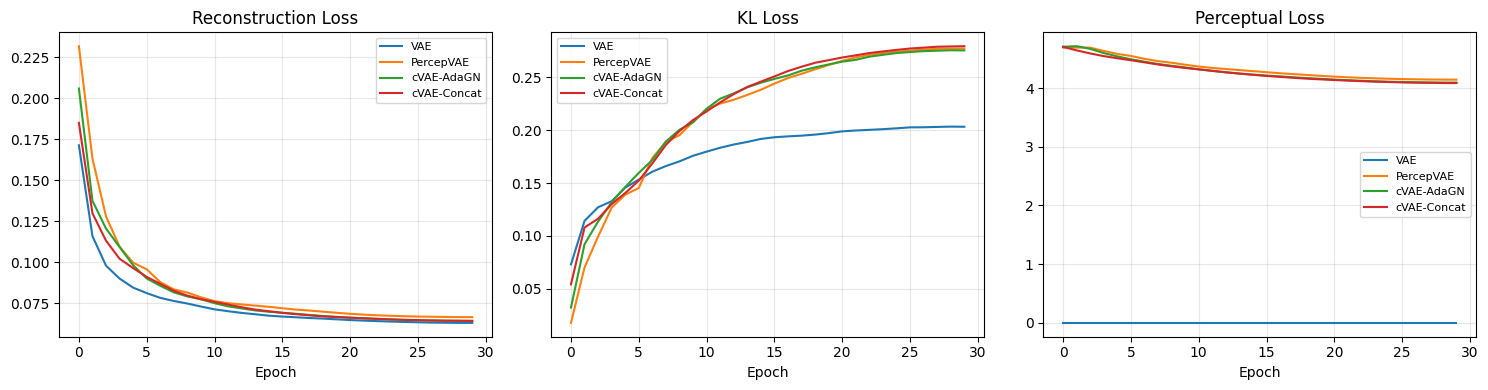

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes,
                           ["recon", "kl", "percep"],
                           ["Reconstruction Loss", "KL Loss", "Perceptual Loss"]):
    for hist, label in [(hist_vae, "VAE"), (hist_percep, "PercepVAE"),
                        (hist_cvae_ada, "cVAE-AdaGN"), (hist_cvae_cat, "cVAE-Concat")]:
        ax.plot(hist[key], label=label)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{experiment_dir}/training_curves.png", dpi=150)
plt.show()

## 8 · Evaluation (FID & IS)

In [ ]:
# Instantiate all three models
# vae_model      = VAE(CFG)
# percep_model   = PercepVAE(CFG)
# cvae_adagn     = cVAE(CFG, conditioning_mode="adagn")
# cvae_concat    = cVAE(CFG, conditioning_mode="concat")


In [ ]:
# cvae_adagn

cVAE(
  (class_emb): Embedding(10, 128)
  (encoder): Encoder(
    (input_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (blocks): ModuleList(
      (0-1): 2 x UNetResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (skip): Identity()
        (attn): AttentionBlock(
          (norm): GroupNorm(8, 64, eps=1e-05, affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
          )
        )
      )
      (2): DownSample(
        (c1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (c2): Conv2d(64, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
      )
      (3): UNet

In [ ]:
# vae_model.load_state_dict(
#     torch.load("./with_KL_equals_1/checkpoints/vae.pt", map_location="cuda")
# )
# vae_model.to("cuda")
# vae_model.eval()


# percep_model.load_state_dict(
#     torch.load("./with_KL_equals_1/checkpoints/percep_vae.pt", map_location="cuda")
# )
# percep_model.to("cuda")
# percep_model.eval()


# cvae_adagn.load_state_dict(
#     torch.load("./with_KL_equals_1/checkpoints/cvae_adagn.pt", map_location="cuda")
# )
# cvae_adagn.to("cuda")
# cvae_adagn.eval()


# cvae_concat.load_state_dict(
#     torch.load("./with_KL_equals_1/checkpoints/cvae_concat.pt", map_location="cuda")
# )
# cvae_concat.to("cuda")

# cvae_concat.eval()
# vae_model.eval()
# percep_model.eval()
# cvae_adagn.eval()
# cvae_concat.eval()

RuntimeError: Error(s) in loading state_dict for VAE:
	Missing key(s) in state_dict: "encoder.blocks.0.attn.norm.weight", "encoder.blocks.0.attn.norm.bias", "encoder.blocks.0.attn.attn.in_proj_weight", "encoder.blocks.0.attn.attn.in_proj_bias", "encoder.blocks.0.attn.attn.out_proj.weight", "encoder.blocks.0.attn.attn.out_proj.bias", "encoder.blocks.1.attn.norm.weight", "encoder.blocks.1.attn.norm.bias", "encoder.blocks.1.attn.attn.in_proj_weight", "encoder.blocks.1.attn.attn.in_proj_bias", "encoder.blocks.1.attn.attn.out_proj.weight", "encoder.blocks.1.attn.attn.out_proj.bias", "encoder.blocks.3.attn.norm.weight", "encoder.blocks.3.attn.norm.bias", "encoder.blocks.3.attn.attn.in_proj_weight", "encoder.blocks.3.attn.attn.in_proj_bias", "encoder.blocks.3.attn.attn.out_proj.weight", "encoder.blocks.3.attn.attn.out_proj.bias", "encoder.blocks.4.attn.norm.weight", "encoder.blocks.4.attn.norm.bias", "encoder.blocks.4.attn.attn.in_proj_weight", "encoder.blocks.4.attn.attn.in_proj_bias", "enco

In [ ]:
def to_uint8(imgs: torch.Tensor) -> torch.Tensor:
    """[-1,1] float → [0,255] uint8 (expected by torchmetrics)."""
    imgs = ((imgs.clamp(-1, 1) + 1) / 2 * 255).byte()
    return imgs


@torch.no_grad()
def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    model_type: str = "vae",
    n_gen: int = 5000,
    device=DEVICE,
) -> dict:
    """
    Computes FID and IS.
    - FID compares generated samples to test-set real images.
    - IS uses only generated samples.
    """
    model.eval()
    fid_metric = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    is_metric  = InceptionScore(normalize=False).to(device)

    # feed real images
    n_real = 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        fid_metric.update(to_uint8(imgs), real=True)
        n_real += len(imgs)
        if n_real >= n_gen:
            break

    # generate fake images
    bs    = 128
    n_gen = min(n_gen, n_real)
    done  = 0
    while done < n_gen:
        batch = min(bs, n_gen - done)
        if model_type == "cvae":
            labels = torch.randint(0, 10, (batch,), device=device)
            fakes  = model.sample(labels)
        else:
            fakes = model.sample(batch, device)
        fakes_u8 = to_uint8(fakes)
        fid_metric.update(fakes_u8, real=False)
        is_metric.update(fakes_u8)
        done += batch

    fid_val       = fid_metric.compute().item()
    is_mean, is_std = is_metric.compute()
    return {"FID": fid_val, "IS_mean": is_mean.item(), "IS_std": is_std.item()}


# Run evaluation
results = {}
for name, m, mtype in [
    ("VAE",         vae_model,    "vae"),
    ("PercepVAE",   percep_model, "vae"),
    ("cVAE-AdaGN",  cvae_adagn,   "cvae"),
    ("cVAE-Concat", cvae_concat,  "cvae"),
]:
    print(f"Evaluating {name} …")
    scores = evaluate_model(m, test_loader, model_type=mtype)
    results[name] = scores
    print(f"  FID={scores['FID']:.2f}  IS={scores['IS_mean']:.2f}±{scores['IS_std']:.2f}")

# summary table
print("\n" + "─"*50)
print(f"{'Model':<18} {'FID':>8} {'IS (mean)':>12} {'IS (std)':>10}")
print("─"*50)
for name, s in results.items():
    print(f"{name:<18} {s['FID']:>8.2f} {s['IS_mean']:>12.2f} {s['IS_std']:>10.2f}")

Evaluating VAE …
  FID=327.36  IS=1.69±0.04
Evaluating PercepVAE …
  FID=275.79  IS=2.22±0.06
Evaluating cVAE-AdaGN …


RuntimeError: Expected all tensors to be on the same device, but got index is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA__index_select)

## 9 · Visualisations

In [ ]:
# helpers
def denorm(t: torch.Tensor) -> np.ndarray:
    """[-1,1] tensor → HWC uint8 numpy."""
    t = (t.clamp(-1, 1) + 1) / 2
    return t.permute(1, 2, 0).cpu().numpy()


def make_grid_img(imgs: torch.Tensor, nrow: int = 8) -> np.ndarray:
    """(N,3,H,W) → numpy grid."""
    grid = torchvision.utils.make_grid(imgs.clamp(-1, 1), nrow=nrow,
                                        normalize=True, value_range=(-1, 1))
    return grid.permute(1, 2, 0).cpu().numpy()

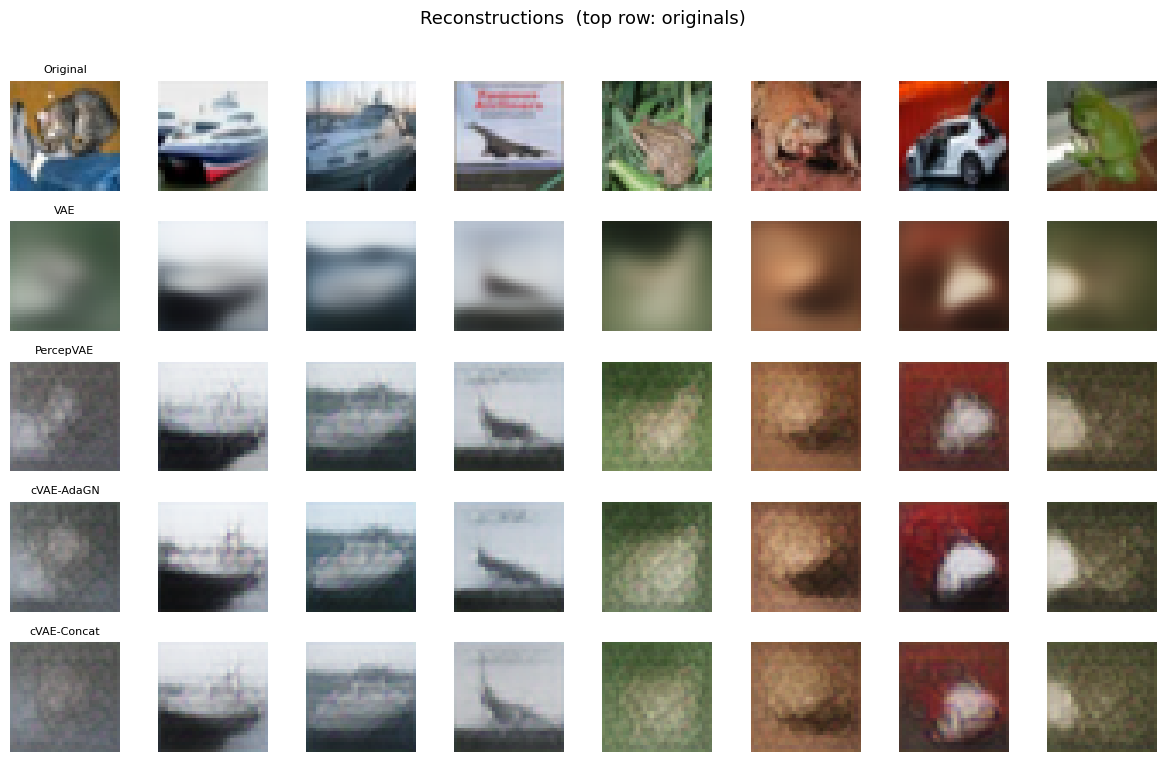

In [ ]:
# Reconstruction comparison

@torch.no_grad()
def plot_reconstructions(models_dict: dict, loader: DataLoader,
                         n: int = 8, save_path: str = None):
    """
    For each model shows: original | reconstructed.
    models_dict: {name: (model, is_conditional)}
    """
    imgs, labels = next(iter(loader))
    imgs, labels = imgs[:n].to(DEVICE), labels[:n].to(DEVICE)

    n_models = len(models_dict)
    fig, axes = plt.subplots(n_models + 1, n, figsize=(n * 1.5, (n_models + 1) * 1.5))
    fig.suptitle("Reconstructions  (top row: originals)", fontsize=13, y=1.01)

    for j in range(n):
        axes[0, j].imshow(denorm(imgs[j]))
        axes[0, j].axis("off")
        if j == 0:
            axes[0, j].set_title("Original", fontsize=8)

    for i, (name, (model, is_cond)) in enumerate(models_dict.items(), start=1):
        model.eval()
        if is_cond:
            recon, _, _ = model(imgs, labels)
        else:
            recon, _, _ = model(imgs)
        for j in range(n):
            axes[i, j].imshow(denorm(recon[j]))
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(name, fontsize=8)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


models_for_recon = {
    "VAE":          (vae_model,    False),
    "PercepVAE":    (percep_model, False),
    "cVAE-AdaGN":   (cvae_adagn,   True),
    "cVAE-Concat":  (cvae_concat,  True),
}
plot_reconstructions(models_for_recon, test_loader, n=8,
                     save_path=f"{experiment_dir}/reconstructions.png")

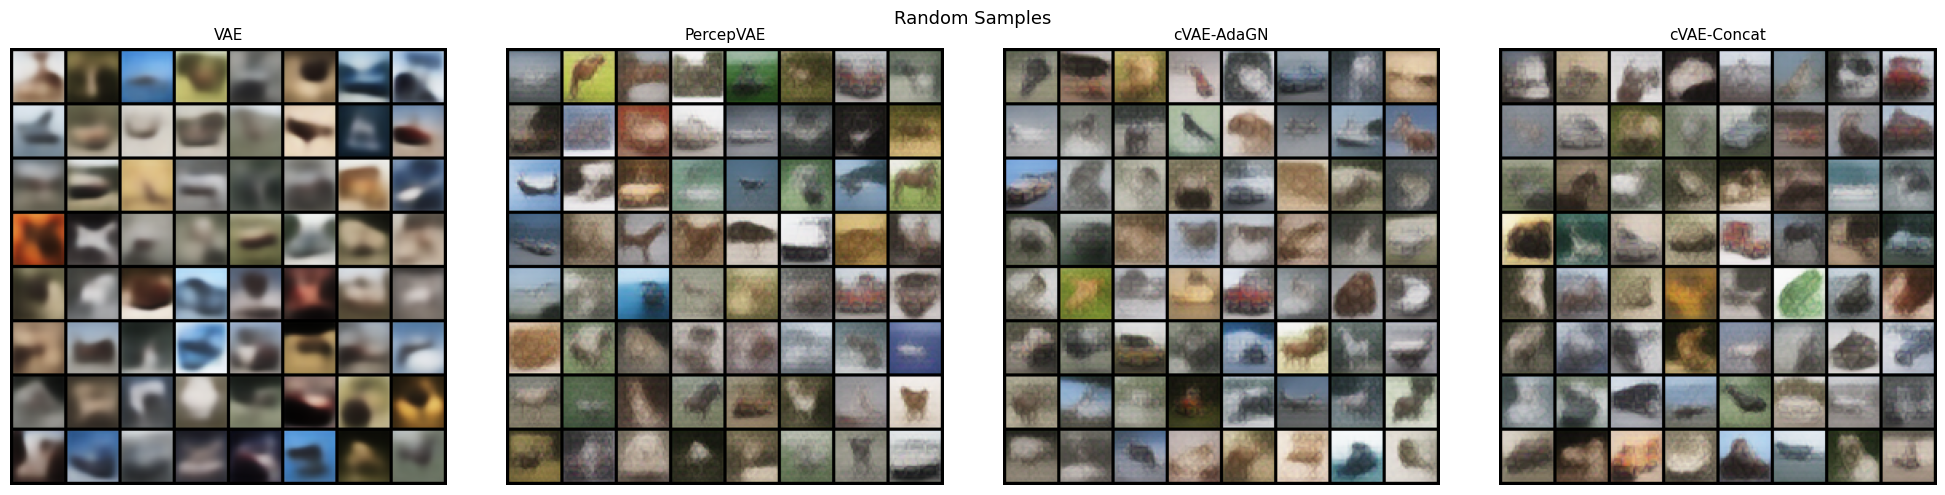

In [ ]:
# Random samples per model

@torch.no_grad()
def plot_samples(models_dict: dict, n: int = 64, nrow: int = 8,
                 save_path: str = None):
    n_models = len(models_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(n_models * 5, 5))
    if n_models == 1:
        axes = [axes]

    for ax, (name, (model, is_cond)) in zip(axes, models_dict.items()):
        model.eval()
        if is_cond:
            labels = torch.randint(0, 10, (n,), device=DEVICE)
            samples = model.sample(labels)
        else:
            samples = model.sample(n, DEVICE)
        ax.imshow(make_grid_img(samples, nrow=nrow))
        ax.set_title(name, fontsize=11)
        ax.axis("off")

    plt.suptitle("Random Samples", fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_samples(models_for_recon, n=64, save_path=f"{experiment_dir}/samples.png")

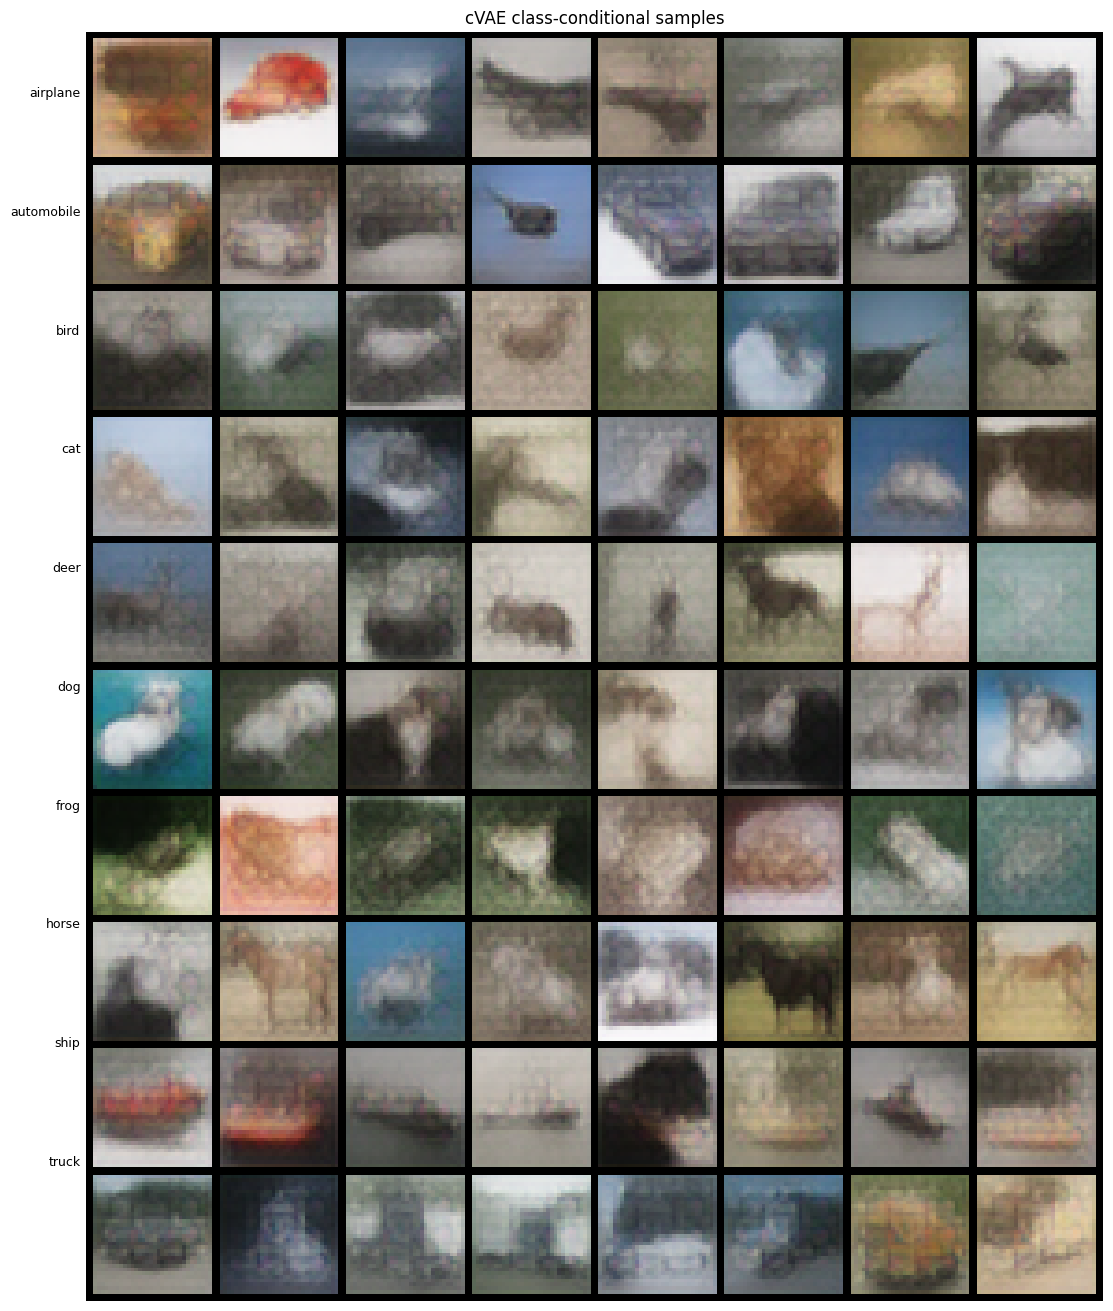

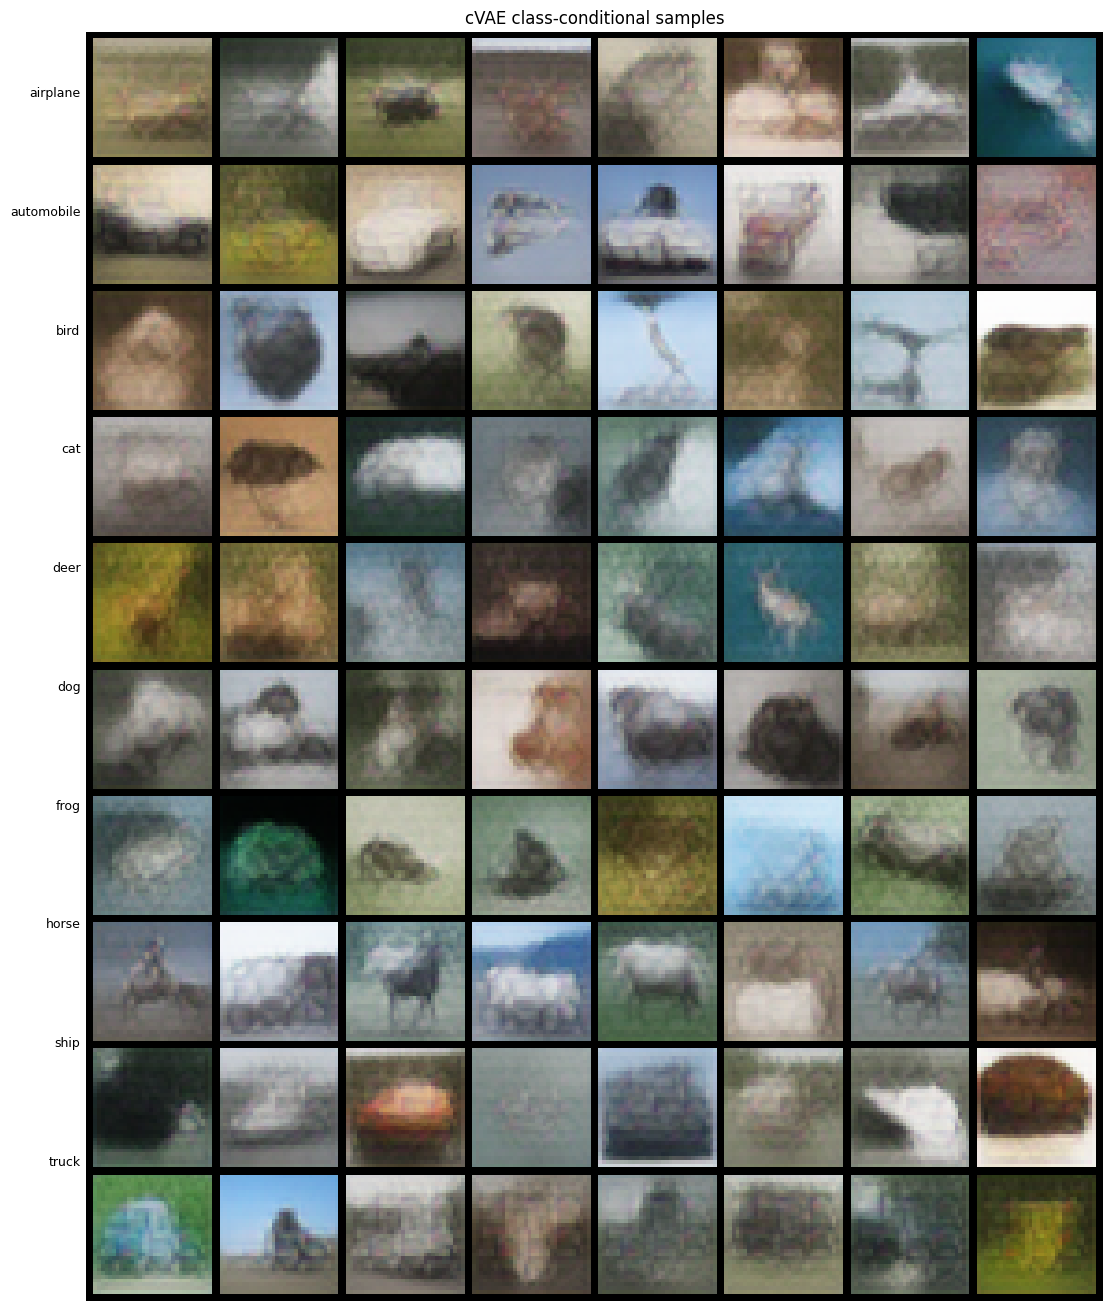

In [ ]:
# Conditional generation by class (cVAE)

@torch.no_grad()
def plot_class_samples(model: nn.Module, n_per_class: int = 8,
                       save_path: str = None):
    model.eval()
    rows = []
    for cls in range(10):
        lbs   = torch.full((n_per_class,), cls, dtype=torch.long, device=DEVICE)
        samps = model.sample(lbs)
        rows.append(samps)
    grid = torch.cat(rows, dim=0)        # (10*n_per_class, 3, H, W)

    fig, ax = plt.subplots(figsize=(n_per_class * 1.4, 10 * 1.4))
    ax.imshow(make_grid_img(grid, nrow=n_per_class))
    ax.axis("off")

    # y-axis class labels
    img_h = 32
    for i, cls_name in enumerate(CIFAR10_CLASSES):
        ax.text(-2, i * img_h + img_h / 2, cls_name,
                va="center", ha="right", fontsize=9)

    ax.set_title("cVAE class-conditional samples", fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_class_samples(cvae_adagn, n_per_class=8, save_path=f"{experiment_dir}/cvae_adagn_class_samples.png")
plot_class_samples(cvae_concat, n_per_class=8, save_path=f"{experiment_dir}/cvae_concat_class_samples.png")

C:\Users\MohamedAtia.Emam\AppData\Local\Temp\ipykernel_13468\2062007206.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


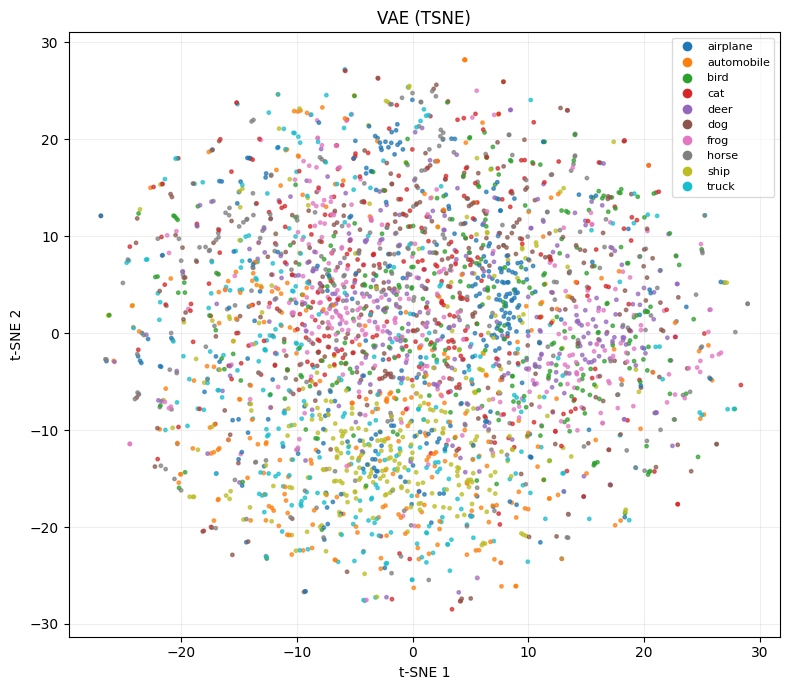

C:\Users\MohamedAtia.Emam\AppData\Local\Temp\ipykernel_13468\2062007206.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


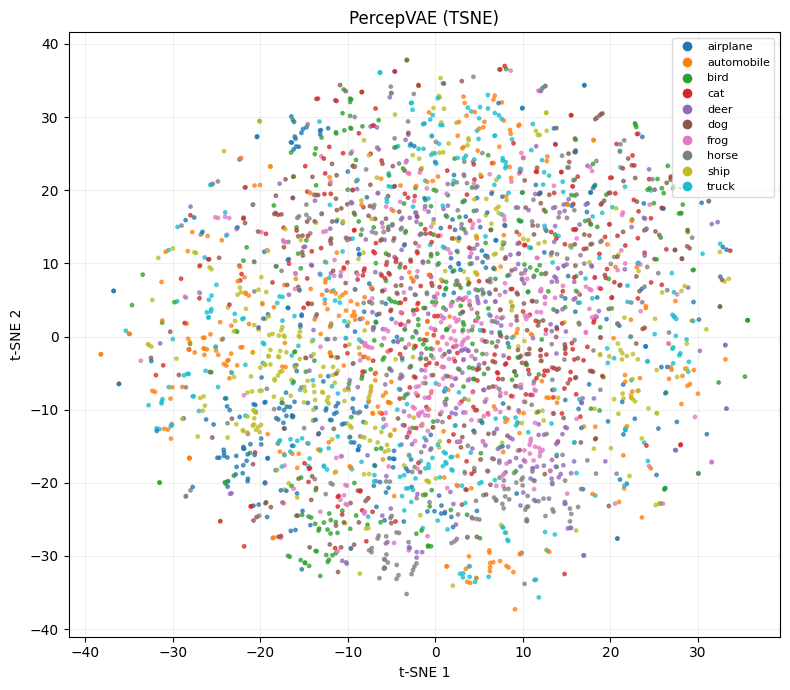

C:\Users\MohamedAtia.Emam\AppData\Local\Temp\ipykernel_13468\2062007206.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


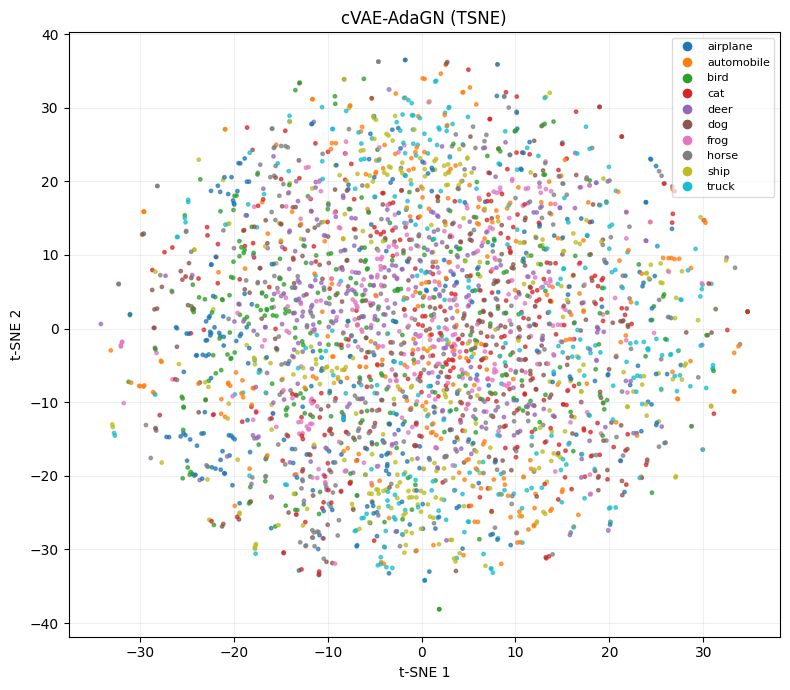

C:\Users\MohamedAtia.Emam\AppData\Local\Temp\ipykernel_13468\2062007206.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


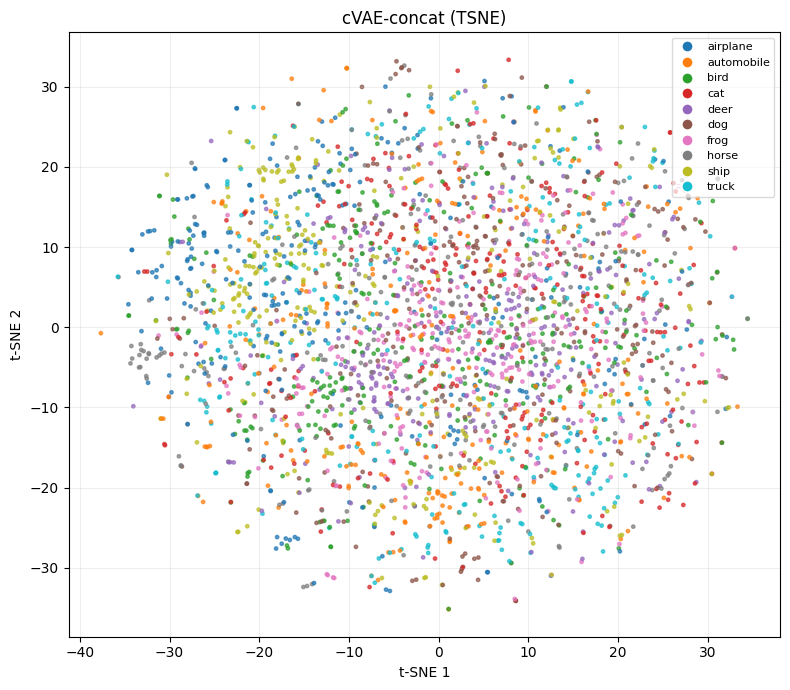

In [ ]:
# Latent space
@torch.no_grad()
def extract_latents(model: nn.Module, loader: DataLoader,
                    max_samples: int = 3000) -> tuple:
    model.eval()
    mus, labs = [], []
    for imgs, labels in loader:
        mu, _ = model.encoder(imgs.to(DEVICE))
        mus.append(mu.cpu())
        labs.append(labels)
        if sum(len(l) for l in labs) >= max_samples:
            break
    mus  = torch.cat(mus,  dim=0)[:max_samples].numpy()
    labs = torch.cat(labs, dim=0)[:max_samples].numpy()
    return mus, labs


def plot_latent_space(model: nn.Module, loader: DataLoader,
                      title: str = "Latent Space",
                      method: str = "tsne",      # "tsne" | "pca"
                      max_samples: int = 3000,
                      save_path: str = None):
    mus, labs = extract_latents(model, loader, max_samples)

    if method == "pca":
        coords = PCA(n_components=2).fit_transform(mus)
        xlabel, ylabel = "PC1", "PC2"
    else:
        coords = TSNE(n_components=2, perplexity=40, max_iter=800,
                      random_state=42, n_jobs=-1).fit_transform(mus)
        xlabel, ylabel = "t-SNE 1", "t-SNE 2"

    fig, ax = plt.subplots(figsize=(8, 7))
    cmap = plt.cm.get_cmap("tab10", 10)
    sc   = ax.scatter(coords[:, 0], coords[:, 1], c=labs,
                      cmap=cmap, s=6, alpha=0.7, vmin=0, vmax=9)
    handles = [plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=cmap(i), markersize=8,
                           label=CIFAR10_CLASSES[i]) for i in range(10)]
    ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{title} ({method.upper()})", fontsize=12)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


for mname, mmodel in [("VAE",        vae_model),
                      ("PercepVAE",  percep_model),
                      ("cVAE-AdaGN", cvae_adagn),
                      ("cVAE-concat", cvae_concat)]:
    plot_latent_space(mmodel, test_loader, title=mname, method="tsne",
                      save_path=f"{experiment_dir}/latent_{mname.lower().replace('-','_')}.png")

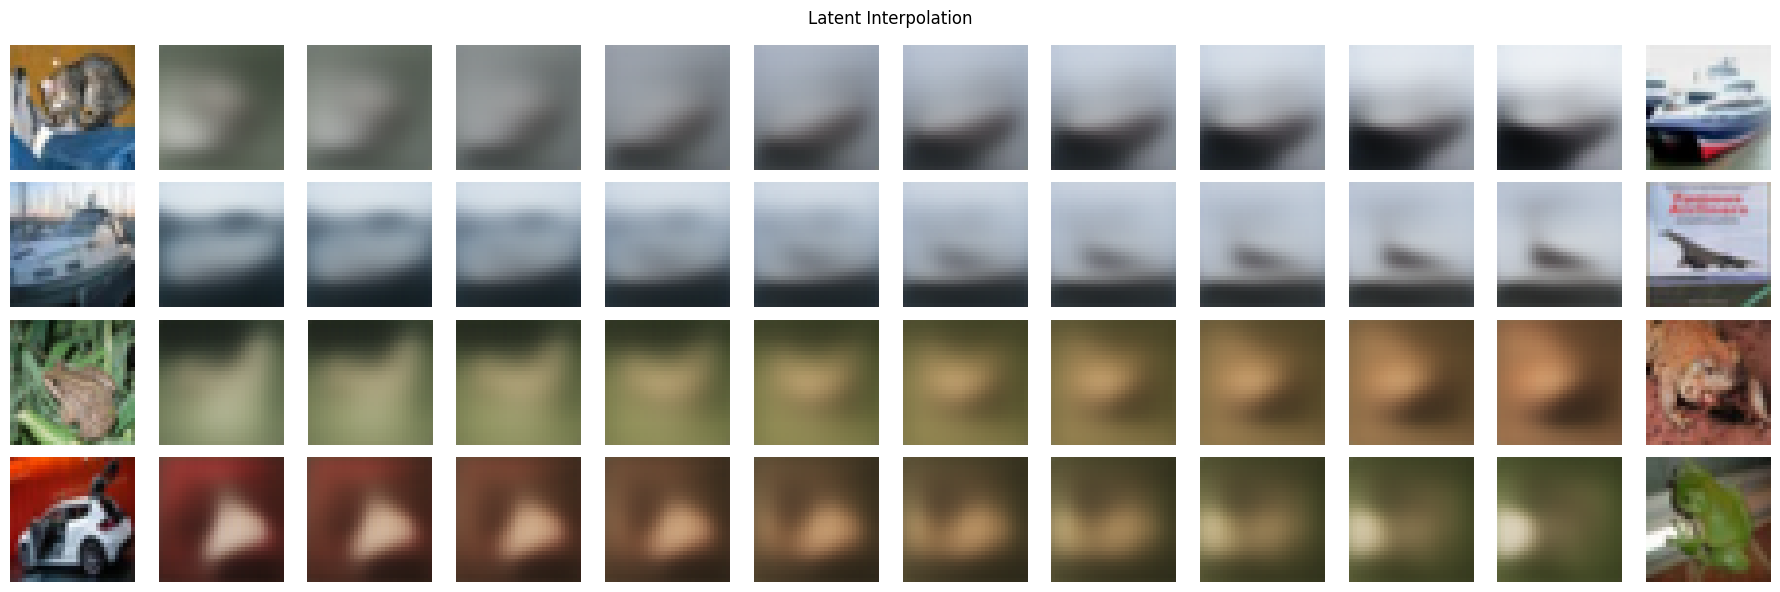

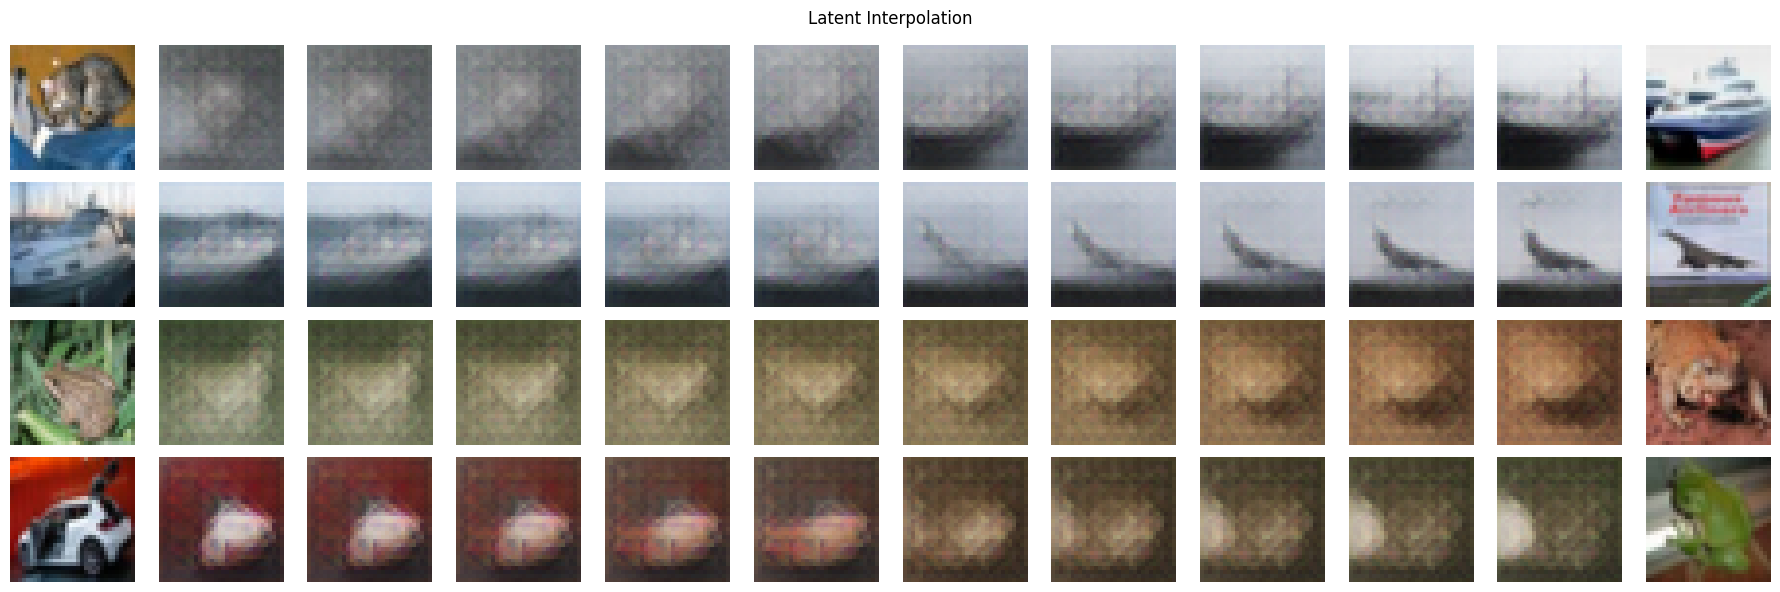

In [ ]:
# Latent interpolation

@torch.no_grad()
def plot_interpolation(model: nn.Module, loader: DataLoader,
                       steps: int = 10, n_pairs: int = 4,
                       model_type: str = "vae",
                       save_path: str = None):
    model.eval()
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

    fig, axes = plt.subplots(n_pairs, steps + 2,
                              figsize=((steps + 2) * 1.5, n_pairs * 1.5))
    fig.suptitle("Latent Interpolation", fontsize=12)

    for row in range(n_pairs):
        i1, i2 = 2 * row, 2 * row + 1
        mu1, _ = model.encoder(imgs[i1:i1+1])
        mu2, _ = model.encoder(imgs[i2:i2+1])

        axes[row, 0].imshow(denorm(imgs[i1]))
        axes[row, 0].axis("off")
        axes[row, -1].imshow(denorm(imgs[i2]))
        axes[row, -1].axis("off")

        for s, α in enumerate(np.linspace(0, 1, steps)):
            z = (1 - α) * mu1 + α * mu2
            if model_type == "cvae":
                # use source label for left half, target for right half
                lbl = labels[i1:i1+1] if α < 0.5 else labels[i2:i2+1]
                c   = model.class_emb(lbl)
                if model.mode == "adagn":
                    out = model.decoder(z, c)
                else:
                    out = model.decoder(torch.cat([z, c], dim=-1))
            else:
                out = model.decoder(z)
            axes[row, s + 1].imshow(denorm(out[0]))
            axes[row, s + 1].axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


plot_interpolation(vae_model,   test_loader, steps=10, n_pairs=4,
                   model_type="vae",  save_path=f"{experiment_dir}/interp_vae.png")
plot_interpolation(cvae_adagn,  test_loader, steps=10, n_pairs=4,
                   model_type="cvae", save_path=f"{experiment_dir}/interp_cvae.png")

In [ ]:
# Save checkpoints

os.makedirs(f"{experiment_dir}/checkpoints", exist_ok=True)
for name, m in [("vae", vae_model), ("percep_vae", percep_model),
                ("cvae_adagn", cvae_adagn), ("cvae_concat", cvae_concat)]:
    torch.save(m.state_dict(), f"{experiment_dir}/checkpoints/{name}.pt")
    print(f"Saved {experiment_dir}/checkpoints/{name}.pt")

Saved with_KL_equals_one_over_ten_for_30_epoch_with_atten/checkpoints/vae.pt
Saved with_KL_equals_one_over_ten_for_30_epoch_with_atten/checkpoints/percep_vae.pt
Saved with_KL_equals_one_over_ten_for_30_epoch_with_atten/checkpoints/cvae_adagn.pt
Saved with_KL_equals_one_over_ten_for_30_epoch_with_atten/checkpoints/cvae_concat.pt
